In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('cleaned_cp_dataset.csv')

In [3]:
df.head(10)

,formula,T,Cp
0,B2O3,1400.0,134.306
1,B2O3,1300.0,131.294
2,B2O3,1200.0,128.072
3,B2O3,1100.0,124.516
4,B2O3,1000.0,120.625
5,B2O3,900.0,116.190
6,B2O3,800.0,111.169
7,B2O3,723.0,106.692
8,B2O3,700.0,105.228
9,B2O3,600.0,98.115


In [4]:
sample_materials = df['formula'].unique()[:5]

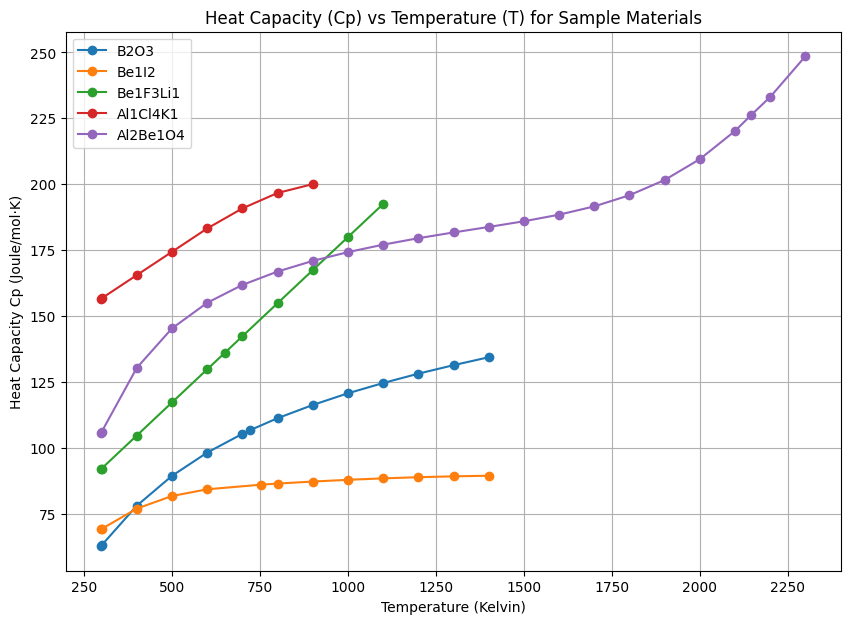

In [9]:
plt.figure(figsize=(10, 7))
for mat in sample_materials:
    subset = df[df['formula'] == mat]
    plt.plot(subset['T'], subset['Cp'], marker='o', label=mat)

plt.title('Heat Capacity (Cp) vs Temperature (T) for Sample Materials')
plt.xlabel('Temperature (Kelvin)')
plt.ylabel('Heat Capacity Cp (Joule/mol·K)')
plt.legend()
plt.grid(True)
plt.show()

In [10]:
def classify_family(formula):
    if 'O' in formula and 'C' not in formula and 'N' not in formula:
        return 'Oxide'
    elif 'C' in formula:
        return 'Carbide'
    elif 'N' in formula:
        return 'Nitride'
    else:
        return 'Other'

In [11]:
df['family'] = df['formula'].apply(classify_family)
df_grouped = df[df['family'].isin(['Oxide', 'Carbide', 'Nitride'])]

In [12]:
family_stats = df_grouped.groupby(['family', 'T'])['Cp'].agg(['mean', 'std']).reset_index()

In [13]:
print("✅ Chemical family grouping and statistical aggregation complete.")

✅ Chemical family grouping and statistical aggregation complete.
